# Parte 2 — Fine-tuning Completo
### Todos los pesos del encoder se actualizan

**Prerequisito:** haber ejecutado `part-1-data.ipynb`

```
[CLS] token_1 ... token_n [SEP]
  ↓
DistilBERT Encoder  ← se actualiza (lr = 2e-5)
  ↓
pre_classifier → classifier → logits
```

In [ ]:
# !pip install 'transformers[torch]' 'accelerate>=1.1.0' datasets evaluate scikit-learn -q

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from datasets import load_from_disk
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
)
import evaluate
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

from dotenv import load_dotenv
import os

SEED             = 42
MODEL_CHECKPOINT = "distilbert-base-uncased"
DATASET_PATH     = "./tokenized_dataset"
HF_REPO          = "jdmartinev/imdb-distilbert-full"  # <-- cambia esto
BATCH_SIZE       = 32
EPOCHS           = 2
LR               = 2e-5
ID2LABEL         = {0: "negative", 1: "positive"}
LABEL2ID         = {"negative": 0, "positive": 1}

torch.manual_seed(SEED)
print(f"Device: {'cuda' if torch.cuda.is_available() else 'cpu'}")

load_dotenv()  # reads .env and sets environment variables
token = os.environ["HF_TOKEN"]

Device: cuda


In [8]:
from huggingface_hub import login

login(token=token)

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


## 1. Cargar dataset tokenizado

In [2]:
tokenized_dataset = load_from_disk(DATASET_PATH)
tokenizer         = AutoTokenizer.from_pretrained(MODEL_CHECKPOINT)
data_collator     = DataCollatorWithPadding(tokenizer=tokenizer)
print(tokenized_dataset)

DatasetDict({
    train: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 8000
    })
    validation: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
})


## 2. Modelo

In [3]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_CHECKPOINT, num_labels=2, id2label=ID2LABEL, label2id=LABEL2ID)

n_total    = sum(p.numel() for p in model.parameters())
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total: {n_total:,}  |  Entrenables: {n_trainable:,}  ({n_trainable/n_total*100:.1f}%)")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total: 66,955,010  |  Entrenables: 66,955,010  (100.0%)


## 3. Métricas

In [4]:
acc_metric = evaluate.load("accuracy")
f1_metric  = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        "accuracy": acc_metric.compute(predictions=preds, references=labels)["accuracy"],
        "f1_macro": f1_metric.compute(predictions=preds, references=labels, average="macro")["f1"],
    }

## 4. Entrenamiento

In [11]:
n_train_steps = (len(tokenized_dataset["train"]) // BATCH_SIZE) * EPOCHS

training_args = TrainingArguments(
    output_dir                  = "./checkpoints/full_finetuning",
    num_train_epochs            = EPOCHS,
    per_device_train_batch_size = BATCH_SIZE,
    per_device_eval_batch_size  = BATCH_SIZE,
    learning_rate               = LR,
    weight_decay                = 0.01,
    warmup_steps                = int(0.1 * n_train_steps),
    lr_scheduler_type           = "linear",
    eval_strategy               = "epoch",
    save_strategy               = "epoch",
    load_best_model_at_end      = True,
    metric_for_best_model       = "f1_macro",
    logging_steps               = 50,
    report_to                   = "none",
    seed                        = SEED,
    fp16                        = torch.cuda.is_available(),
    push_to_hub                 = True,
    hub_model_id                = HF_REPO,
)

trainer = Trainer(
    model             = model,
    args              = training_args,
    train_dataset     = tokenized_dataset["train"],
    eval_dataset      = tokenized_dataset["validation"],
    processing_class  = tokenizer,
    data_collator     = data_collator,
    compute_metrics   = compute_metrics,
)

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.279493,0.272814,0.894000,0.894000
2,0.194789,0.275940,0.894000,0.893991


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=500, training_loss=0.3028595123291016, metrics={'train_runtime': 119.6509, 'train_samples_per_second': 133.722, 'train_steps_per_second': 4.179, 'total_flos': 1059739189248000.0, 'train_loss': 0.3028595123291016, 'epoch': 2.0})

## 5. Curvas de entrenamiento

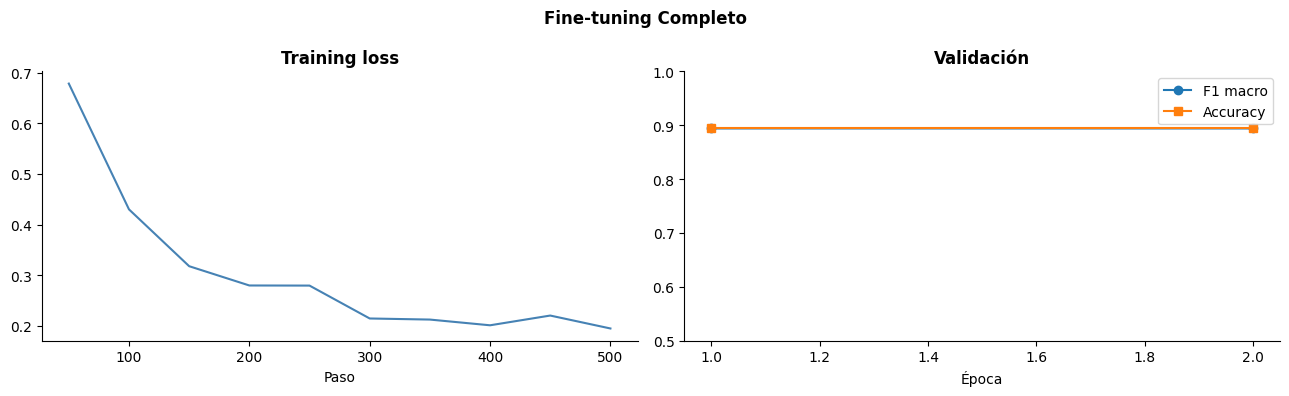

In [12]:
logs       = pd.DataFrame(trainer.state.log_history)
train_logs = logs[logs["loss"].notna()]
eval_logs  = logs[logs["eval_loss"].notna()]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(train_logs["step"], train_logs["loss"], color="steelblue")
axes[0].set_title("Training loss", fontweight="bold"); axes[0].set_xlabel("Paso")
axes[0].spines[["top", "right"]].set_visible(False)

axes[1].plot(eval_logs["epoch"], eval_logs["eval_f1_macro"], marker="o", label="F1 macro")
axes[1].plot(eval_logs["epoch"], eval_logs["eval_accuracy"], marker="s", label="Accuracy")
axes[1].set_title("Validación", fontweight="bold"); axes[1].set_xlabel("Época")
axes[1].set_ylim(0.5, 1.0); axes[1].legend()
axes[1].spines[["top", "right"]].set_visible(False)

plt.suptitle("Fine-tuning Completo", fontweight="bold"); plt.tight_layout(); plt.show()

## 6. Evaluación en test

              precision    recall  f1-score   support

    negative     0.8958    0.8940    0.8949      1000
    positive     0.8942    0.8960    0.8951      1000

    accuracy                         0.8950      2000
   macro avg     0.8950    0.8950    0.8950      2000
weighted avg     0.8950    0.8950    0.8950      2000



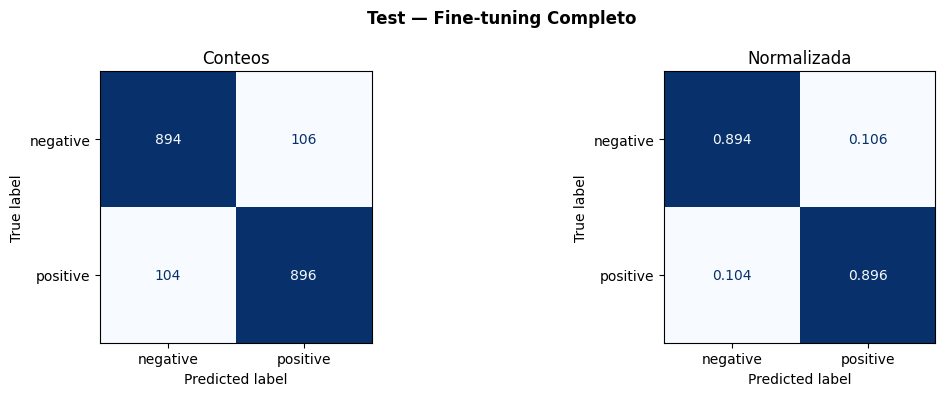

{'test_loss': 0.24890917539596558, 'test_accuracy': 0.895, 'test_f1_macro': 0.894999894999895, 'test_runtime': 4.1098, 'test_samples_per_second': 486.638, 'test_steps_per_second': 15.329}


In [13]:
output = trainer.predict(tokenized_dataset["test"])
preds  = np.argmax(output.predictions, axis=1)
labels = output.label_ids

print(classification_report(labels, preds, target_names=["negative", "positive"], digits=4))

cm = confusion_matrix(labels, preds)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ConfusionMatrixDisplay(cm, display_labels=["negative", "positive"]).plot(
    ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Conteos")
ConfusionMatrixDisplay(cm.astype(float)/cm.sum(axis=1,keepdims=True),
                       display_labels=["negative","positive"]).plot(
    ax=axes[1], colorbar=False, cmap="Blues", values_format=".3f")
axes[1].set_title("Normalizada")
plt.suptitle("Test — Fine-tuning Completo", fontweight="bold")
plt.tight_layout(); plt.show()

# Guardar métricas para el notebook de comparación
metrics_full = output.metrics
print(metrics_full)

## 7. Push to Hub

In [14]:
# Requiere haber hecho: huggingface-cli login
trainer.push_to_hub(commit_message="Fine-tuning completo IMDB")
print(f"Modelo publicado en: https://huggingface.co/{HF_REPO}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Modelo publicado en: https://huggingface.co/jdmartinev/imdb-distilbert-full
